# DS 3001: Foundations of Machine Learning
## Assignment 4: Regularization, Logistic Regression, & Neural Networks
## (100 Possible Points)

### **Your Name**: Phan, Paris

### **Your Computing ID:** auj4yx

### **Sign Honor Pledge Here:** 

On my honor as a student, I have neither given nor received unauthorized aid on this assignment.

signed, paris

### **Assignment Description**

The questions for the fourth and final assignment of the semester, `Assignment 4`, are found below. The questions are split between the topics we discussed in the regularization, logistic regression, and neural network notebooks. These questions give you the chance to combine all that we've learned into tasks that you could run into as a data scientist.

For help with formatting your markdown responses in text cells, reference this [markdown style cheat sheet](https://www.markdownguide.org/cheat-sheet/).

**AI Use:** For Assignment 4, you may use autofill code suggestions that Google Colab provides to you in the code blocks. You should not assume that the suggestions are always correct. Make sure that you think critically about whether the suggestions are correct or not and if they make sense with what you are trying to achieve. You may NOT use AI for the written responses in the markdown cells. I want to know what you are thinking about for your justifications, not what an LLM produces. If you have any need for clarification on this policy, please reach out to me earlier than later.

**Submission Instructions:** For a complete submission, please upload your completed Assignment 4 notebook (.ipynb) on Canvas. All code cells must be ran before final submission. **If your code cells are not ran, you will not receive credit for the question.**

#### Setting up your directory

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os # For changing directory

# working locally!
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# path_to_DS_3001_folder = '/content/drive/MyDrive/DS-3001/assignments/'
# path_to_DS_3001_folder = './'

# Update the path to your folder for the class
# Where you stored the data from the previous noteboook
path_to_DS_3001_folder = '/Users/parisphan/Github/DS-3001/assignments/'
os.chdir(path_to_DS_3001_folder)

### **Question 1 (8 Points Total):** Regularized Regression Conceptual Questions

**Q1.1 (2 Points):** What is the intuition of adding a penalty to the mean squared error (MSE) loss function, such that the penalty grows with the "size" (absolute or squared value) of the model parameters?

**Answer here:**

EDITED:
Adding a penalty to the MSE discourages the model from assigning overly large values to the coefficients. When coefficients are large, the model becomes highly sensitive to small changes in the input features, which leads to overfitting to the noise in the training data. By penalizing larger coefficients, the optimizer must balance fitting the data well (low MSE) against keeping the model simple (small coefficients). This encourages more generalizable models that perform better on unseen data.

**Q1.2 (2 Points):** How does regularization provide a way of exploring the bias-variance trade-off?

**Answer here:**

EDITED:
The regularization parameter $\alpha$ controls the strength of the penalty. When $\alpha$ is small (near zero), the penalty has little effect and the model behaves like standard regression — low bias but potentially high variance (overfitting). When $\alpha$ is large, the penalty dominates, forcing coefficients toward zero, which increases bias but reduces variance (simpler, more stable model). By varying $\alpha$ across a range of values, we can systematically explore different points on the bias-variance tradeoff and select the $\alpha$ that minimizes overall prediction error using cross-validation.

**Q1.3 (2 Points):** What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems? Hint: think about what happens to the coefficients with each.

**Answer here:**

EDITED:
LASSO uses an L1 penalty (sum of absolute values of coefficients), while Ridge uses an L2 penalty (sum of squared values of coefficients). The key difference is in how they shrink coefficients: LASSO can drive coefficients exactly to zero, effectively performing automatic feature selection by removing irrelevant predictors from the model entirely. Ridge shrinks all coefficients toward zero but rarely sets any exactly to zero, keeping all features in the model with reduced magnitudes. LASSO tends to produce sparse solutions and is preferred when many features are irrelevant; Ridge is better when most features are meaningful but need magnitude control.

**Q1.4 (2 Points):** How is the penalty $\alpha$ typically selected?

**Answer here:**

EDITED:
The penalty $\alpha$ is typically selected using cross-validation. A grid of candidate $\alpha$ values is defined, and for each value, the model is trained on the training folds and evaluated on the held-out validation fold. This process is repeated across all folds, and the average validation error (e.g., MSE) is computed for each $\alpha$. The $\alpha$ that produces the lowest average cross-validated error is selected as optimal. Functions like `LassoCV` in scikit-learn automate this process.

### **Question 2 (25 Points Total):** Implementing LASSO Regression

**Q2.1 (4 Points)**. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle using `Make_Year` and the current year we are in (2026). Using `Mileage_Run` and `Age` for all observations in the data set:

  1. Use `PolynomialFeatures` to create a third degree expansion of both variables. [Documentation is found here.](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)

  2. `StandardScaler` to $z$-score normalize them. [Documentation is found here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

  3. Print the first five rows of your new data frame after expansion and scaling.

**Note:** Do not consider a train test spilt yet right now. Apply the expansion and scaling to all observations.

In [ ]:
# Answer Here
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

cars = pd.read_csv('data/cars_hw.csv')
cars['Age'] = 2026 - cars['Make_Year']

X = cars[['Mileage_Run', 'Age']]
y = cars['Price']

# 1. Polynomial expansion (degree 3)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

# 2. Standard scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_poly),
    columns=poly.get_feature_names_out()
)

# 3. Print first five rows
print(X_scaled.head())

   Mileage_Run       Age  Mileage_Run^2  Mileage_Run Age     Age^2  \
0     0.124692 -0.013092      -0.137673        -0.045119 -0.157264   
1    -0.872334  0.341858      -0.791316        -0.677034  0.190081   
2    -0.493517 -0.722993      -0.600623        -0.665157 -0.742267   
3    -0.241655 -0.013092      -0.434732        -0.301067 -0.157264   
4    -0.674578 -0.013092      -0.700583        -0.603528 -0.157264   

   Mileage_Run^3  Mileage_Run^2 Age  Mileage_Run Age^2     Age^3  
0      -0.294615          -0.230767          -0.195586 -0.270422  
1      -0.661216          -0.718186          -0.564890  0.044089  
2      -0.581863          -0.648004          -0.700911 -0.718398  
3      -0.492295          -0.458906          -0.364354 -0.270422  
4      -0.627064          -0.663078          -0.563792 -0.270422  


**Q2.2 (2 Points)**: Using the design matrix you created, run linear regression to predict the `Price`.

1. Look at the coefficients of the fit model. Print them to the screen.


In [ ]:
# Answer Here
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_scaled, y)

coef_df = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Coefficient': lr.coef_
})
print(coef_df)
print(f"\nIntercept: {lr.intercept_}")

             Feature   Coefficient
0        Mileage_Run  9.117748e+05
1                Age -2.481722e+05
2      Mileage_Run^2 -2.072926e+05
3    Mileage_Run Age -1.671212e+06
4              Age^2  3.505507e+05
5      Mileage_Run^3 -6.514490e+04
6  Mileage_Run^2 Age  3.388195e+05
7  Mileage_Run Age^2  7.167816e+05
8              Age^3 -2.100379e+05

Intercept: 741019.4672131146


2. What is the sign (positive or negative) for the interaction term between `Mileage_Run` and `Age`?

**Answer Here:**

EDITED:
The interaction term `Mileage_Run Age` has a **negative** coefficient (-1,671,212). This makes intuitive sense: cars that are both old AND have high mileage see a compounding reduction in price beyond what each factor alone would predict. The negative interaction means the combined effect of age and mileage on price is greater than the sum of their individual effects.

**Q2.3 (5 Points):** Use `LassoCV` to regularize your linear regression model.
  - Use **20-fold cross validation**.
  - Use this grid of alphas: `alphas = np.logspace(1, 5, 20)`.
  - Use a random state of `3001`
  - Run the LASSO regularization optimization for `50000` steps.
  - **Note:** Ensure that you do not have any *data leakage* between your train and test split in the cross validation. Use an Sklearn [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) and [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html) to ensure there is no data leakage between the train and test splits in the cross validation.

In [ ]:
# Answer Here
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

alphas = np.logspace(1, 5, 20)

# Pipeline: PolynomialFeatures -> StandardScaler -> LassoCV
# ColumnTransformer prevents data leakage by applying preprocessing inside CV
preprocessor = ColumnTransformer(
    transformers=[
        ('poly_scale', Pipeline([
            ('poly', PolynomialFeatures(degree=3, include_bias=False)),
            ('scaler', StandardScaler())
        ]), ['Mileage_Run', 'Age'])
    ]
)

pipeline_lasso = Pipeline([
    ('preprocessor', preprocessor),
    ('lasso', LassoCV(cv=20, alphas=alphas, random_state=3001, max_iter=50000))
])

X_raw = cars[['Mileage_Run', 'Age']]
pipeline_lasso.fit(X_raw, y)

lasso_model = pipeline_lasso.named_steps['lasso']
print(f"Optimal alpha: {lasso_model.alpha_}")

Optimal alpha: 112.88378916846884


**Q2.4 (2 Points):**

1. Plot the cross-validated MSE by $\alpha$.

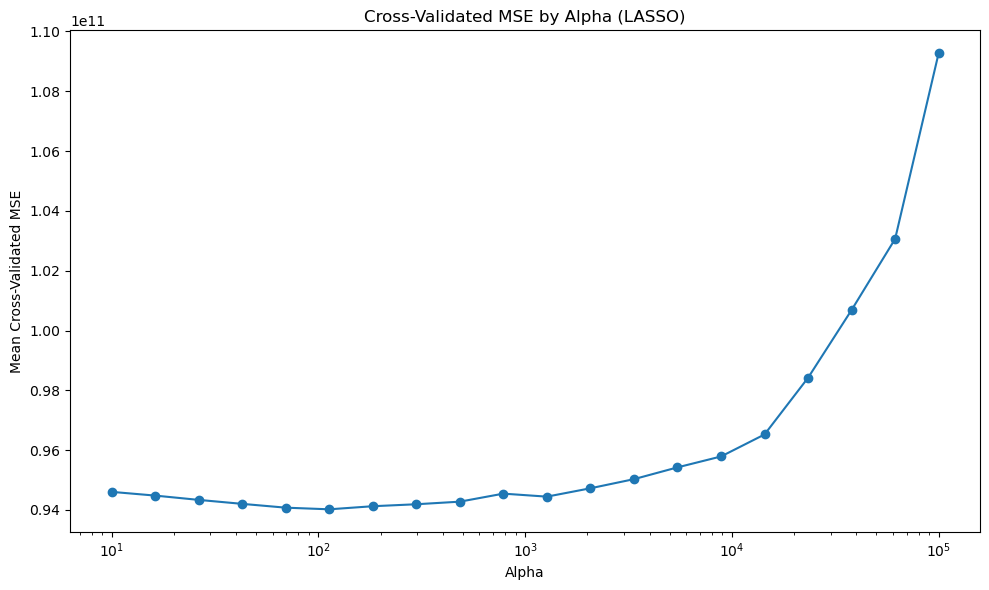

In [ ]:
# Answer Here
mean_mse = np.mean(lasso_model.mse_path_, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(lasso_model.alphas_, mean_mse, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Mean Cross-Validated MSE')
plt.title('Cross-Validated MSE by Alpha (LASSO)')
plt.tight_layout()
plt.show()

2. What value of $\alpha$ would you pick for the optimal LASSO regression model? What value of the MSE does it produce? Print both values to the screen in the code block below.

In [ ]:
# Answer Here
best_alpha = lasso_model.alpha_
best_idx = np.where(lasso_model.alphas_ == best_alpha)[0][0]
best_mse = mean_mse[best_idx]

print(f"Optimal alpha: {best_alpha:.4f}")
print(f"MSE at optimal alpha: {best_mse:.4f}")

Optimal alpha: 112.8838
MSE at optimal alpha: 94021981225.7595


**Q2.5 (4 Points):** Plot the coefficient paths by $\alpha$ and include a line for the value of $\alpha$ that minimzes the MSE.

**Hint**: use the [lasso_path](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.lasso_path.html) function. Set the max iterations for the `lasso_path` function to the same value as before.

**Technical Note:**
> `lasso_path` is a standalone function and cannot be used directly
inside an Sklearn Pipeline. Because of this, you can pass the scaled data set directly into the `lasso_path` funciton.

> This complicates our ability to counteract data leakage for this question since the preprocessing is applied to the whole data set. Because we are using `lasso_path` purely for **visualization** of coefficient paths, not for model selection, this is acceptable here. Model selection was already handled properly using `LassoCV` inside a Pipeline in Q2.3.

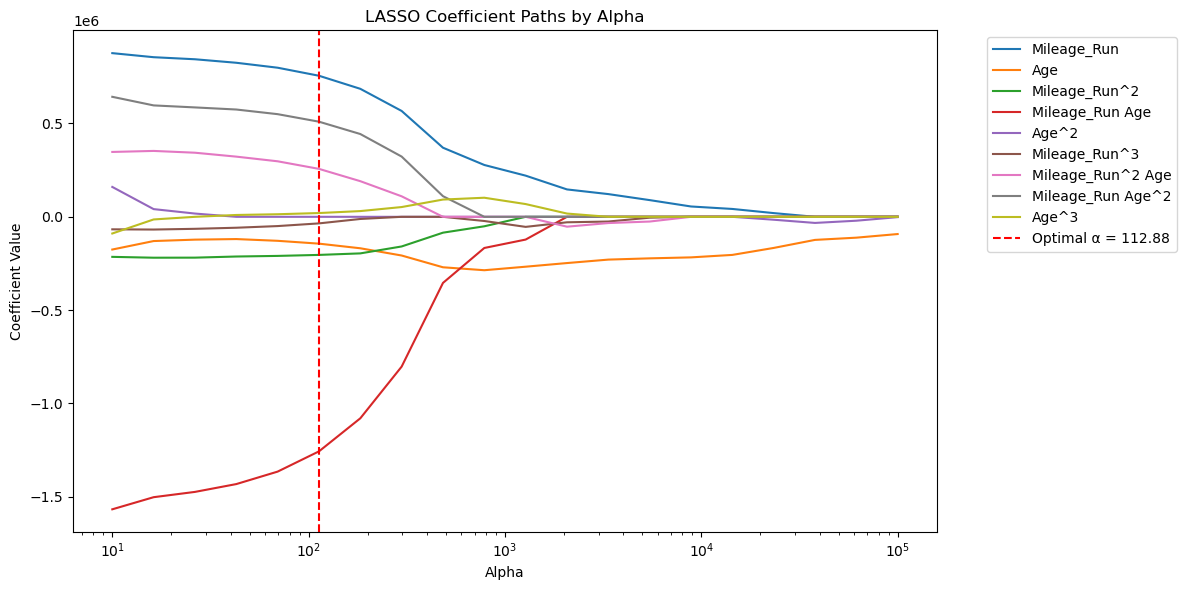

In [ ]:
# Answer Here
from sklearn.linear_model import lasso_path

alphas_path, coef_path, _ = lasso_path(X_scaled, y, alphas=alphas, max_iter=50000)

plt.figure(figsize=(12, 6))
for i in range(coef_path.shape[0]):
    plt.plot(alphas_path, coef_path[i, :], label=X_scaled.columns[i])

plt.xscale('log')
plt.axvline(x=lasso_model.alpha_, color='red', linestyle='--', label=f'Optimal α = {lasso_model.alpha_:.2f}')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('LASSO Coefficient Paths by Alpha')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Q2.6 (4 Points):**

1. Print out the coefficient value of each variable for the optimal value of $\alpha$ according to the `lasso_path()` function.

In [ ]:
# Answer Here
# Find the closest alpha in the lasso_path to the optimal alpha from LassoCV
optimal_idx = np.argmin(np.abs(alphas_path - lasso_model.alpha_))
optimal_coefs = coef_path[:, optimal_idx]

coef_at_optimal = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Coefficient': optimal_coefs
})
print(f"Coefficients at optimal alpha ({lasso_model.alpha_:.4f}):")
print(coef_at_optimal)

Coefficients at optimal alpha (112.8838):
             Feature   Coefficient
0        Mileage_Run  7.558053e+05
1                Age -1.437229e+05
2      Mileage_Run^2 -2.040878e+05
3    Mileage_Run Age -1.256627e+06
4              Age^2 -0.000000e+00
5      Mileage_Run^3 -3.521171e+04
6  Mileage_Run^2 Age  2.568714e+05
7  Mileage_Run Age^2  5.096840e+05
8              Age^3  2.020048e+04


2. Based on the coefficients above, which features are actually selected?

**Answer Here:**

EDITED:
The features selected (non-zero coefficients) are: `Mileage_Run`, `Age`, `Mileage_Run^2`, `Mileage_Run Age`, `Mileage_Run^3`, `Mileage_Run^2 Age`, `Mileage_Run Age^2`, and `Age^3`. The only feature set to zero is `Age^2`.

3. Based on the coefficients above, what proportion are set equal to zero?

**Answer Here:**

EDITED:
1 out of 9 features (approximately 11.1%) is set to zero by LASSO — specifically, the `Age^2` term.

**Q2.7 (4 Points)**:

1. Print out the coefficients both from the original linear regression and the optimally regularized coefficients (LASSO).


In [ ]:
# Answer Here
comparison = pd.DataFrame({
    'Feature': X_scaled.columns,
    'OLS Coefficient': lr.coef_,
    'LASSO Coefficient': optimal_coefs
})
print(comparison)

             Feature  OLS Coefficient  LASSO Coefficient
0        Mileage_Run     9.117748e+05       7.558053e+05
1                Age    -2.481722e+05      -1.437229e+05
2      Mileage_Run^2    -2.072926e+05      -2.040878e+05
3    Mileage_Run Age    -1.671212e+06      -1.256627e+06
4              Age^2     3.505507e+05      -0.000000e+00
5      Mileage_Run^3    -6.514490e+04      -3.521171e+04
6  Mileage_Run^2 Age     3.388195e+05       2.568714e+05
7  Mileage_Run Age^2     7.167816e+05       5.096840e+05
8              Age^3    -2.100379e+05       2.020048e+04


2. Do any coefficients increase in magnitude from linear regression to LASSO? Which ones?

**Answer Here:**

EDITED:
No, none of the coefficients increase in magnitude from OLS to LASSO. All coefficients either decrease in magnitude or are shrunk to zero. This is the expected behavior of LASSO regularization, as the L1 penalty pushes all coefficients toward zero.

3. Do any coefficients change sign? Which ones and in what direction?

**Answer Here:**

EDITED:
Yes, the `Age^3` coefficient changes sign: it goes from negative (-210,038) in OLS to positive (20,200) in LASSO. Additionally, `Age^2` changed from positive (350,551) to zero. The sign change in `Age^3` can occur because LASSO is re-balancing the contributions of correlated polynomial terms — when some coefficients are shrunk, others may adjust to compensate, potentially flipping sign.

## **Question 3 (8 Points Total):** Logistic Regression Conceptual Questions

**Q3.1 (2 Points):** What does the activation function do to the outputs of the linear model in logistic regression?

**Answer Here:**

EDITED:
The activation function in logistic regression is the sigmoid function, which transforms the linear combination of inputs ($\mathbf{w} \cdot \mathbf{x} + b$) from an unbounded real number into a value between 0 and 1. This transformation allows the output to be interpreted as the probability of belonging to the positive class. Without the sigmoid, the output could be any real number, which would not be a valid probability.


**Q3.2 (2 Points):** What loss/cost function do we use for logistic regression with two possible outcomes? How does it compare to the MSE that we use for linear regression?

**Answer Here:**

EDITED:
We use binary cross-entropy (also called log loss) for logistic regression with two outcomes. It measures how well the predicted probabilities match the actual binary labels (0 or 1). Unlike MSE, which penalizes the squared difference between predictions and targets (suitable for continuous outcomes), log loss penalizes confident wrong predictions very heavily and rewards confident correct predictions. MSE would create a non-convex loss surface when combined with the sigmoid, making optimization difficult, whereas log loss maintains convexity and works naturally with probability outputs.

**Q3.3 (2 Points):** How can we use logistic regression for classification? Think about what the outputs of logistic regression represent.

**Answer Here:**

EDITED:
Logistic regression outputs the predicted probability of belonging to each class (via the sigmoid function). To convert these probabilities into class predictions, we apply a decision threshold — typically 0.5. If the predicted probability of the positive class exceeds 0.5, we classify the observation as the positive class (1); otherwise, we classify it as the negative class (0). The threshold can be adjusted depending on the application to prioritize precision or recall.

**Q3.4 (2 Points):** What is the relationship between logistic regression and neural networks? Mention at least two ways they relate.

**Answer Here:**

EDITED:
1. **Logistic regression is a special case of a neural network.** Specifically, logistic regression is mathematically equivalent to a neural network with no hidden layers — just an input layer connected directly to an output layer with a sigmoid activation function. It is the simplest possible neural network.

2. **Both use gradient-based optimization.** Both logistic regression and neural networks learn their parameters (weights and biases) by minimizing a loss function using gradient descent (or variants like stochastic gradient descent and Adam). They both compute gradients of the loss with respect to the parameters and iteratively update the parameters to reduce the loss.

## **Question 4 (25 Points Total):** Implementing Regularized Logistic Regression

**Q4.1 (4 Points):** Import the `heart_failure_clinical_records_dataset.csv` dataset that we worked with during class. This question will give you the opportunity to explore an expanded feature space for this same data set using Logistic Regression, with and without regularization.

1. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results.

2. Use `PolynomialFeatures` with `interaction_only=True` to interact each of the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking` with each other.

3. Concatenate these results into your scaled feature/covariate/design matrix. Print the first 5 rows of your new matrix.

**Note:** Do not consider a train/test split yet.

In [ ]:
# Answer Here

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

heart = pd.read_csv('data/heart_failure_clinical_records_dataset.csv')

# 1. Degree-3 polynomial expansion + standard scaling for numeric variables
numeric_cols = ['age', 'ejection_fraction', 'serum_creatinine']
X_numeric = heart[numeric_cols]

poly_numeric = PolynomialFeatures(degree=3, include_bias=False)
X_poly_numeric = poly_numeric.fit_transform(X_numeric)
poly_numeric_names = poly_numeric.get_feature_names_out()

scaler_numeric = StandardScaler()
X_scaled_numeric = scaler_numeric.fit_transform(X_poly_numeric)

# 2. Interaction terms for categorical variables
cat_cols = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']
X_cat = heart[cat_cols]

poly_cat = PolynomialFeatures(interaction_only=True, include_bias=False)
X_interactions = poly_cat.fit_transform(X_cat)
poly_cat_names = poly_cat.get_feature_names_out()

# 3. Concatenate into design matrix
X_full = pd.DataFrame(
    np.hstack([X_scaled_numeric, X_interactions]),
    columns=list(poly_numeric_names) + list(poly_cat_names)
)

print(X_full.head())

        age  ejection_fraction  serum_creatinine     age^2  \
0  1.192945          -1.530560          0.490057  1.177180   
1 -0.491279          -0.007077         -0.284552 -0.539187   
2  0.350833          -1.530560         -0.090900  0.252982   
3 -0.912335          -1.530560          0.490057 -0.885761   
4  0.350833          -1.530560          1.264666  0.252982   

   age ejection_fraction  age serum_creatinine  ejection_fraction^2  \
0              -0.939354              0.777328            -1.197120   
1              -0.267742             -0.365953            -0.146835   
2              -1.167019             -0.031334            -1.197120   
3              -1.508517              0.115061            -1.197120   
4              -1.167019              1.237428            -1.197120   

   ejection_fraction serum_creatinine  serum_creatinine^2     age^3  ...  \
0                           -0.287340            0.073541  1.124026  ...   
1                           -0.214284           

**Q4.2 (3 Points):** Using your new design matrix, fit a logistic regression model with no regularization to predict `DEATH_EVENT`. Print out the coefficients and intercept of your model.

In [ ]:
# Answer Here

from sklearn.linear_model import LogisticRegression

y_heart = heart['DEATH_EVENT']

log_reg_heart = LogisticRegression(penalty=None, max_iter=10000, random_state=3001)
log_reg_heart.fit(X_full, y_heart)

coef_df_heart = pd.DataFrame({
    'Feature': X_full.columns,
    'Coefficient': log_reg_heart.coef_[0]
})
print(coef_df_heart)
print(f"\nIntercept: {log_reg_heart.intercept_[0]}")

                                   Feature  Coefficient
0                                      age    12.081822
1                        ejection_fraction   -16.379586
2                         serum_creatinine    -6.613035
3                                    age^2   -31.884838
4                    age ejection_fraction     5.495595
5                     age serum_creatinine     5.088145
6                      ejection_fraction^2    16.513750
7       ejection_fraction serum_creatinine    24.294086
8                       serum_creatinine^2   -11.218862
9                                    age^3    17.868746
10                 age^2 ejection_fraction    -0.577067
11                  age^2 serum_creatinine     5.950649
12                 age ejection_fraction^2     1.830829
13  age ejection_fraction serum_creatinine   -19.482745
14                  age serum_creatinine^2     1.807010
15                     ejection_fraction^3    -6.753792
16    ejection_fraction^2 serum_creatinine    -4

/opt/homebrew/Caskroom/miniconda/base/envs/ds-3001/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


2. Are there any sign patterns that appear counterintuitive? Why?

**Answer Here:**

EDITED:
Yes, several sign patterns appear counterintuitive. For example, `serum_creatinine` has a negative coefficient (-6.61), yet higher serum creatinine levels typically indicate worsening kidney function and should be associated with increased death risk. Similarly, `diabetes` (-0.50) and `smoking` (-0.84) both have negative coefficients, even though both are known risk factors for heart failure mortality. These counterintuitive signs arise because we are working with polynomial and interaction features — the linear term alone does not represent the full effect of a variable when higher-order terms are also present.

3. Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?

**Answer Here:**

EDITED:
Yes. The higher-order and interaction terms modify the effect of the base variables. For instance, while `diabetes` alone has a negative coefficient, its interactions with `high_blood_pressure` (0.90) and `smoking` (1.21) are strongly positive. This means having diabetes alone may slightly reduce predicted death risk, but having diabetes combined with high blood pressure or smoking substantially increases risk. Similarly, `serum_creatinine` has a negative linear term but a positive interaction with `ejection_fraction` (24.29), and its squared and cubed terms further shape the overall relationship. The total effect of each variable is the sum of all terms involving it, not just the linear coefficient, so what appears contradictory in isolation makes sense when considering the full polynomial model.

**Q4.3 (10 Points):** Next, fit a logistic regression model with a Lasso (L1) penalty.

- Look at the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) for the logistic regression function. Identify how to apply the L1 penalty and how they define the strength of the regularization/penalty.
  - **Note:** Be particularly careful with how this function deals with the strength of the constraint in comparison to the other functions we've dealt with. It is not directly `alpha`.

- Investigate a series of `alpha` values. Use a `for` loop to investigate each value of $\alpha$: `alphas = np.logspace(-2, 1, 20)`.

- Use 10-Fold cross validation for each value of alpha.
  - Identify the best value of $\alpha$ using the cross validated binary cross entropy / log loss.
  - Use a random state of `3001`.
  - Ensure that there is **no data leakage** by using a full pipeline inside the for loop to apply the same feature engineering as in **Q4.1** (Degree 3 polynomial expansion of numeric columns, standard scaling of numeric columns, and interaction terms for categorical variables).

- Helpful functions for you to look at:
  - Sklearn [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).
    - When using an L1 penalty, set the `solver` to `saga`.
  - Sklearn [KFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.KFold.html).
  - Sklearn [cross_val_score](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html).
    - When using a pipeline, you can pass the pipeline directly into this function instead of the model.
    - To get the binary cross entropy that we use for logistic regression, set the scoring to `neg_log_loss` which means *negative log loss*. You'll want to negate this to get the value for binary cross entropy.'
  - Sklearn [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html)
  - Sklearn [ColumnTransformer](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html)

**Note:** This code chunk, if done properly, may take approximately 2 to 3 minutes to run. To look at how long the code is taking, consider using [tqdm](https://www.geeksforgeeks.org/python/python-create-progress-bar-using-tqdm-module/) in your for loop.

In [ ]:
# Answer Here

# A helpful import for timing your for loop
from tqdm import tqdm


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

alphas_q4 = np.logspace(-2, 1, 20)
kf = KFold(n_splits=10, shuffle=True, random_state=3001)

numeric_cols_q4 = ['age', 'ejection_fraction', 'serum_creatinine']
cat_cols_q4 = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']

X_heart = heart[numeric_cols_q4 + cat_cols_q4]
y_heart = heart['DEATH_EVENT']

mean_log_losses = []

for alpha in tqdm(alphas_q4):
    C = 1 / alpha  # LogisticRegression uses C = 1/alpha

    preprocessor_q4 = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('poly', PolynomialFeatures(degree=3, include_bias=False)),
                ('scaler', StandardScaler())
            ]), numeric_cols_q4),
            ('cat', PolynomialFeatures(interaction_only=True, include_bias=False), cat_cols_q4)
        ]
    )

    pipeline_q4 = Pipeline([
        ('preprocessor', preprocessor_q4),
        ('classifier', LogisticRegression(
            penalty='l1', C=C, solver='saga',
            random_state=3001, max_iter=10000
        ))
    ])

    scores = cross_val_score(pipeline_q4, X_heart, y_heart, cv=kf, scoring='neg_log_loss')
    mean_log_losses.append(-scores.mean())  # Negate to get positive log loss

mean_log_losses = np.array(mean_log_losses)

  0%|          | 0/20 [00:00<?, ?it/s]/opt/homebrew/Caskroom/miniconda/base/envs/ds-3001/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ds-3001/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ds-3001/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l

**Q4.4 (2 Points):** Find the optimal value of $\alpha$. Plot the cross-validated log loss / binary cross entropy by $\alpha$. Include a line on the graph for the optimal value of $\alpha$.

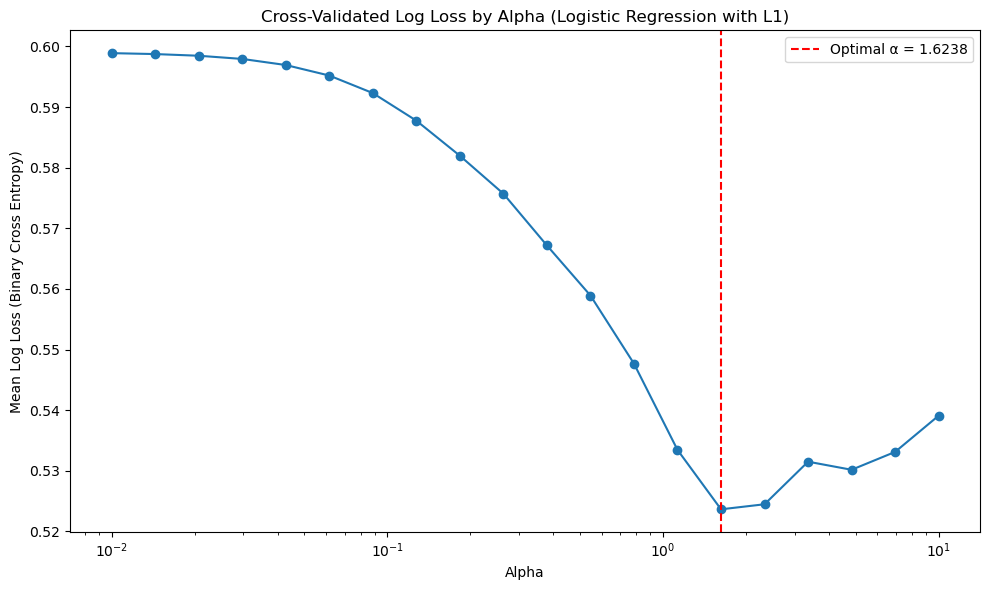

Optimal alpha: 1.6238
Minimum log loss: 0.5237


In [ ]:
# Answer Here

best_idx_q4 = np.argmin(mean_log_losses)
best_alpha_q4 = alphas_q4[best_idx_q4]
best_log_loss = mean_log_losses[best_idx_q4]

plt.figure(figsize=(10, 6))
plt.plot(alphas_q4, mean_log_losses, marker='o')
plt.xscale('log')
plt.axvline(x=best_alpha_q4, color='red', linestyle='--', label=f'Optimal α = {best_alpha_q4:.4f}')
plt.xlabel('Alpha')
plt.ylabel('Mean Log Loss (Binary Cross Entropy)')
plt.title('Cross-Validated Log Loss by Alpha (Logistic Regression with L1)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal alpha: {best_alpha_q4:.4f}")
print(f"Minimum log loss: {best_log_loss:.4f}")

**Q4.5 (4 Points):** Fit your logistic regression model using the optimal value of `alpha` on the entire data set (no train/test split this time). Print the coefficients of the model you fit.

**Hint**: You can get the feature names from your preprocessor (outcome from `ColumnTransformer`) object.

In [ ]:
# Answer Here

best_C_q4 = 1 / best_alpha_q4

preprocessor_final_q4 = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('poly', PolynomialFeatures(degree=3, include_bias=False)),
            ('scaler', StandardScaler())
        ]), numeric_cols_q4),
        ('cat', PolynomialFeatures(interaction_only=True, include_bias=False), cat_cols_q4)
    ]
)

pipeline_final_q4 = Pipeline([
    ('preprocessor', preprocessor_final_q4),
    ('classifier', LogisticRegression(
        penalty='l1', C=best_C_q4, solver='saga',
        random_state=3001, max_iter=10000
    ))
])

pipeline_final_q4.fit(X_heart, y_heart)

# Get feature names from preprocessor
feature_names_q4 = pipeline_final_q4.named_steps['preprocessor'].get_feature_names_out()
coefficients_q4 = pipeline_final_q4.named_steps['classifier'].coef_[0]

coef_df_final_q4 = pd.DataFrame({
    'Feature': feature_names_q4,
    'Coefficient': coefficients_q4
})
print(coef_df_final_q4)
print(f"\nIntercept: {pipeline_final_q4.named_steps['classifier'].intercept_[0]}")

                                        Feature  Coefficient
0                                      num__age     0.000000
1                        num__ejection_fraction    -1.702614
2                         num__serum_creatinine     0.474679
3                                    num__age^2     0.000000
4                    num__age ejection_fraction     0.000000
5                     num__age serum_creatinine     0.000000
6                      num__ejection_fraction^2     0.000000
7       num__ejection_fraction serum_creatinine     0.000000
8                       num__serum_creatinine^2     0.000000
9                                    num__age^3     0.618255
10                 num__age^2 ejection_fraction     0.000000
11                  num__age^2 serum_creatinine     0.076056
12                 num__age ejection_fraction^2     0.000000
13  num__age ejection_fraction serum_creatinine     0.000000
14                  num__age serum_creatinine^2     0.000000
15                     n

/opt/homebrew/Caskroom/miniconda/base/envs/ds-3001/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/ds-3001/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


**Q4.6 (2 Points):** What features remain in the model after regularization? Use the coefficients to identify the remaining features and print the name of each included feature below.

In [ ]:
# Answer Here

selected_features = coef_df_final_q4[coef_df_final_q4['Coefficient'] != 0]
print("Features remaining after L1 regularization:")
for _, row in selected_features.iterrows():
    print(f"  {row['Feature']}: {row['Coefficient']:.6f}")
print(f"\nTotal features selected: {len(selected_features)} out of {len(coef_df_final_q4)}")

Features remaining after L1 regularization:
  num__ejection_fraction: -1.702614
  num__serum_creatinine: 0.474679
  num__age^3: 0.618255
  num__age^2 serum_creatinine: 0.076056
  num__ejection_fraction^3: 0.993200
  num__ejection_fraction^2 serum_creatinine: 0.191181
  num__serum_creatinine^3: -0.053881
  cat__anaemia: 0.102778
  cat__diabetes: 0.004618
  cat__high_blood_pressure: 0.140874
  cat__anaemia diabetes: 0.005360
  cat__diabetes high_blood_pressure: 0.289187
  cat__diabetes smoking: 0.130651
  cat__high_blood_pressure smoking: 0.026188

Total features selected: 14 out of 29


## **Question 5 (8 Points):** Neural Network Conceptual Questions

**Q5.1 (2 Points):** What are the basic building blocks of a neural network? Describe the role of the input layer, hidden layers and nodes, weights / biases, activation functions, and the output layer in an MLP.

**Answer Here:**

EDITED:
- **Input layer:** Receives the raw features and passes them into the network. Each node corresponds to one input feature.
- **Hidden layers and nodes:** Intermediate layers between input and output. Each node computes a weighted sum of its inputs, adds a bias, and applies an activation function. Hidden layers allow the network to learn complex, nonlinear patterns.
- **Weights and biases:** Weights determine the strength of connections between nodes across layers. Biases provide an offset that shifts the activation function, giving the network more flexibility in fitting the data. Both are learned during training.
- **Activation functions:** Applied at each hidden node to introduce nonlinearity (e.g., ReLU, sigmoid). They allow the network to model complex relationships beyond simple linear combinations.
- **Output layer:** Produces the final prediction. For binary classification, it typically has one node with a sigmoid activation to output a probability between 0 and 1.

**Q5.2 (2 Points):** Explain how information flows from the input layer to the output layer in a neural network (MLP). What do the intermediate steps (the values of each hidden node) represent?

**Answer Here:**

EDITED:
Information flows forward through the network via forward propagation. At each layer, the outputs from the previous layer are multiplied by a weight matrix, summed with a bias vector, and then passed through an activation function. This process repeats from the input layer through each hidden layer to the output layer. The intermediate values at each hidden node represent learned features or representations of the input data — they are nonlinear transformations of the original inputs. Each successive layer builds increasingly abstract representations, transforming the raw features into a form that makes the final prediction task easier for the output layer.

**Q5.3 (2 Points):** Why do we need activation functions? What happens if we use a linear activation function (or no activation function) in every layer?

**Answer Here:**

EDITED:
Activation functions introduce nonlinearity into the network, enabling it to learn complex, nonlinear relationships in the data. Without nonlinear activations (i.e., using only linear activations or no activations), each layer would simply compute a linear transformation of its inputs. Since the composition of multiple linear transformations is still a linear transformation, the entire network — regardless of how many layers it has — would collapse into a single linear model equivalent to linear regression. Nonlinear activations are what give deep networks their expressive power to approximate complex functions.

**Q5.4 (2 Points):** How does the number of hidden layers and hidden nodes per layer affect the bias-variance tradeoff?

**Answer Here:**

EDITED:
Increasing the number of hidden layers and nodes per layer increases the model's capacity to learn complex patterns. With few layers/nodes, the model has high bias and low variance — it may be too simple to capture the true relationships in the data (underfitting). With many layers/nodes, the model has low bias but high variance — it can fit the training data very closely, including the noise, leading to overfitting and poor generalization. The challenge is finding the right architecture that balances complexity (low bias) against stability (low variance) for the best performance on unseen data.

## Question 6 (26 Points): Fitting a Neural Network (MLP)


**Q6.1 (1 Point):**

Load in the data set for student dropout probability: `student-dropout-data.csv`. This data set is seperated by semicolon's (`;`) instead of commas (`,`), so include this argument when reading in the file: `delimiter = ';'`. Subset the data to select the following variables of interest:

- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`


In [ ]:
# Answer Here

student = pd.read_csv('data/student-dropout-data.csv', delimiter=';')

cols_of_interest = [
    'Debtor',
    'Tuition fees up to date',
    'Scholarship holder',
    'Age at enrollment',
    'Curricular units 1st sem (approved)',
    'Target'
]

student = student[cols_of_interest]
print(student.head())

   Debtor  Tuition fees up to date  Scholarship holder  Age at enrollment  \
0       0                        1                   0                 20   
1       0                        0                   0                 19   
2       0                        0                   0                 19   
3       0                        1                   0                 20   
4       0                        1                   0                 45   

   Curricular units 1st sem (approved)    Target  
0                                    0   Dropout  
1                                    6  Graduate  
2                                    0   Dropout  
3                                    6  Graduate  
4                                    5  Graduate  


**Q6.2 (4 Points):**

1. Using the `Dropout` target, create a new binary target called `Dropout_binary` that is 1 if `Dropout` is *dropout* and 0 if `Dropout` is either *Enrolled* or *Graduated*.

In [ ]:
# Answer Here

student['Dropout_binary'] = (student['Target'] == 'Dropout').astype(int)
print(student['Dropout_binary'].value_counts())

Dropout_binary
0    3003
1    1421
Name: count, dtype: int64


2. Fit a neural network that predicts the probability for `Dropout_binary` using `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Use the all observations and configure the network as such:
  - **Solver:** Adam
  - **Activation Function:** ReLU
  - **Hidden Layers:** 1
  - **Hidden Nodes:** 8
  - **Number of Iterations:** 2000
  - **Random State:** 3001

**Note:** Make sure your data are scaled properly before fitting the model.

In [ ]:
# Answer Here

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

features_nn = ['Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']
X_nn = student[features_nn]
y_nn = student['Dropout_binary']

scaler_nn = StandardScaler()
X_nn_scaled = scaler_nn.fit_transform(X_nn)

mlp = MLPClassifier(
    solver='adam',
    activation='relu',
    hidden_layer_sizes=(8,),
    max_iter=2000,
    random_state=3001
)
mlp.fit(X_nn_scaled, y_nn)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(8,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",2000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",3001


3. Print the weights and biases of the network below.

In [ ]:
# Answer Here

print("Weights (coefs_):")
for i, w in enumerate(mlp.coefs_):
    print(f"\nLayer {i} weights (shape {w.shape}):")
    print(w)

print("\n" + "="*50)
print("\nBiases (intercepts_):")
for i, b in enumerate(mlp.intercepts_):
    print(f"\nLayer {i} biases (shape {b.shape}):")
    print(b)

Weights (coefs_):

Layer 0 weights (shape (3, 8)):
[[-0.19172034 -0.56062178  0.39145609  0.27828942  1.15193279 -0.32489381
  -0.57164542 -0.17416827]
 [-0.16052793 -0.47464609  0.3454147  -0.76088408  0.64268042  0.17394872
  -0.2311304   0.60674575]
 [-0.39236919 -0.51882547 -0.02742781 -1.0093503   0.60042121 -0.96445318
   0.677677    0.57337037]]

Layer 1 weights (shape (8, 1)):
[[-0.32894497]
 [ 0.1813891 ]
 [ 0.35973195]
 [-0.93407182]
 [-0.70295913]
 [-0.30301447]
 [ 0.83632198]
 [-0.33926487]]


Biases (intercepts_):

Layer 0 biases (shape (8,)):
[-0.89165014  0.76475056 -0.76776891 -0.25733205  0.99259029  0.62705972
  0.76576227 -0.32508172]

Layer 1 biases (shape (1,)):
[-0.13342465]


4. How many weights and biases are returned? Explain why.

**Answer Here:**

EDITED:
There are 4 arrays returned: 2 weight matrices (`coefs_[0]` and `coefs_[1]`) and 2 bias vectors (`intercepts_[0]` and `intercepts_[1]`). This is because the network has 3 layers total (input, 1 hidden, output), and each pair of consecutive layers requires one weight matrix and one bias vector to connect them. So we have weights and biases for the input-to-hidden connection and for the hidden-to-output connection.

5. What are the sizes of each weights and bias matrix? Explain why.

**Answer Here:**

EDITED:
- `coefs_[0]`: shape **(3, 8)** — 3 input features connected to 8 hidden nodes. Each of the 3 inputs has a weight for each of the 8 hidden nodes.
- `intercepts_[0]`: shape **(8,)** — one bias term per hidden node (8 biases total).
- `coefs_[1]`: shape **(8, 1)** — 8 hidden nodes connected to 1 output node. Each hidden node has one weight going to the single output.
- `intercepts_[1]`: shape **(1,)** — one bias term for the single output node.

The sizes are determined by the number of nodes in consecutive layers: (input_size, hidden_size) for the first weight matrix and (hidden_size, output_size) for the second.

**Q6.3 (1 Point):** Now fit a logistic regression model on the same data set with no regularization/penalty.

In [ ]:
# Answer Here

from sklearn.linear_model import LogisticRegression

log_reg_nn = LogisticRegression(penalty=None, max_iter=2000, random_state=3001)
log_reg_nn.fit(X_nn_scaled, y_nn)

/opt/homebrew/Caskroom/miniconda/base/envs/ds-3001/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",3001
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

**Q6.4 (4 Points):**

1. Use your neural network to predict the probability of dropout for each observation in the data set. Do the same for your logistic regression model.

In [ ]:
# Answer Here

nn_probs = mlp.predict_proba(X_nn_scaled)[:, 1]
lr_probs = log_reg_nn.predict_proba(X_nn_scaled)[:, 1]

student['NN_prob'] = nn_probs
student['LR_prob'] = lr_probs

2. Using your neural network predicted probabilities, make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`, and styled by `Scholarship holder`. Include an appropriate title, axis labels, and legend.

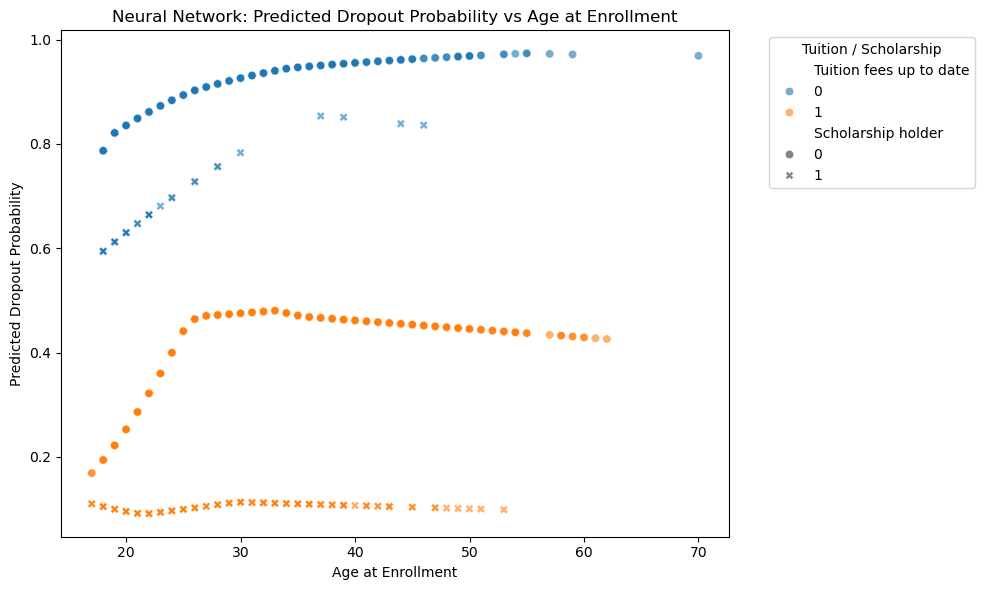

In [ ]:
# Answer Here

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=student,
    x='Age at enrollment',
    y='NN_prob',
    hue='Tuition fees up to date',
    style='Scholarship holder',
    alpha=0.6
)
plt.xlabel('Age at Enrollment')
plt.ylabel('Predicted Dropout Probability')
plt.title('Neural Network: Predicted Dropout Probability vs Age at Enrollment')
plt.legend(title='Tuition / Scholarship', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

3. Create the same plot the logistic regression model's predicted probabilities.

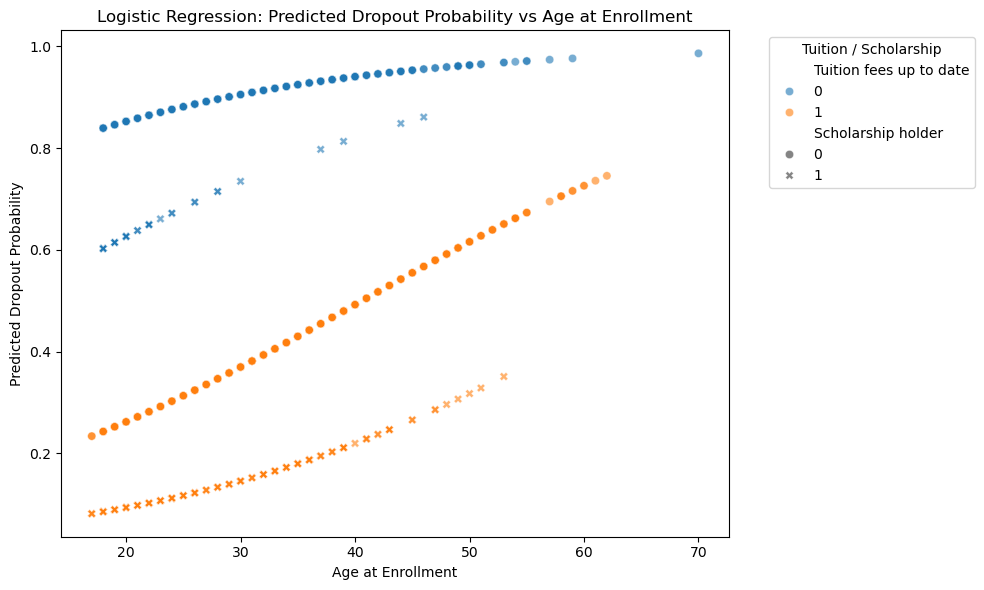

In [ ]:
# Answer Here

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=student,
    x='Age at enrollment',
    y='LR_prob',
    hue='Tuition fees up to date',
    style='Scholarship holder',
    alpha=0.6
)
plt.xlabel('Age at Enrollment')
plt.ylabel('Predicted Dropout Probability')
plt.title('Logistic Regression: Predicted Dropout Probability vs Age at Enrollment')
plt.legend(title='Tuition / Scholarship', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

4. Compare and contrast the predicted probabilities from both plots:
  - What are your main takeaways?
  - Do both models show the same trends?
  - What differences do you see?
  - Why might the trends be different for the different models?

**Answer Here:**

EDITED:
- **Main takeaways:** Both models agree that students who are not up to date on tuition have a higher dropout probability, and that scholarship holders tend to have lower dropout probability. Both also show that dropout probability varies with age.
- **Same trends:** Both models capture the general direction — not paying tuition increases dropout risk, and scholarships are protective.
- **Differences:** The neural network produces more complex, nonlinear patterns in the predicted probabilities across different ages. The logistic regression predictions vary more smoothly and monotonically with age, since it can only model linear relationships in the feature space. The NN may show sharper transitions or non-monotonic patterns because it can learn nonlinear decision boundaries through its hidden layer.
- **Why different:** The neural network has 8 hidden nodes with ReLU activations, allowing it to approximate nonlinear functions of the inputs. Logistic regression is a linear model in the feature space, so it can only produce smooth, monotonic probability curves for each combination of categorical features. The NN can capture interactions and nonlinearities that the logistic regression model cannot.

5. Based on your both of your plots, for what ages does being up to date on tuition seem to reduce dropout probability the most?

**Answer Here:**

EDITED:
Being up to date on tuition appears to reduce dropout probability the most for younger students, roughly in the 18-25 age range. At these ages, the gap between the tuition-up-to-date group and the not-up-to-date group is widest. For older students, the dropout probabilities may converge somewhat, suggesting that other factors beyond tuition become more influential at older ages.

6. Based on your plots above, which students are most at risk of dropping out? What intervations could help these students stay enrolled?

**Answer Here:**

EDITED:
The students most at risk of dropping out are those who are **not up to date on tuition**, **do not hold a scholarship**, and are enrolled at **older ages**. These students consistently show the highest predicted dropout probabilities across both models.

Potential interventions to help these students:
- **Financial aid and tuition payment plans:** Flexible payment options or emergency financial assistance could help students stay current on tuition.
- **Targeted scholarship programs:** Expanding scholarship availability to non-traditional or older students who lack financial support.
- **Academic advising and mentoring:** Proactive outreach to at-risk students, especially older enrollees who may face different challenges than traditional-age students.
- **Early warning systems:** Flagging students who fall behind on tuition for immediate academic and financial support.

7. Using both of your models (neural network and logistic regression), compute the predicted classes for all observations and create a confusion matrix to compare predicted and true class. Report the accuracy of both models.

In [ ]:
# Answer Here

from sklearn.metrics import confusion_matrix, accuracy_score

# Neural Network predictions and confusion matrix
nn_preds = mlp.predict(X_nn_scaled)
nn_cm = pd.crosstab(y_nn, nn_preds, rownames=['Actual'], colnames=['Predicted'])
nn_acc = accuracy_score(y_nn, nn_preds)

print("Neural Network Confusion Matrix:")
print(nn_cm)
print(f"Neural Network Accuracy: {nn_acc:.4f}\n")

# Logistic Regression predictions and confusion matrix
lr_preds = log_reg_nn.predict(X_nn_scaled)
lr_cm = pd.crosstab(y_nn, lr_preds, rownames=['Actual'], colnames=['Predicted'])
lr_acc = accuracy_score(y_nn, lr_preds)

print("Logistic Regression Confusion Matrix:")
print(lr_cm)
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")

Neural Network Confusion Matrix:
Predicted     0    1
Actual              
0          2932   71
1           964  457
Neural Network Accuracy: 0.7660

Logistic Regression Confusion Matrix:
Predicted     0    1
Actual              
0          2836  167
1           901  520
Logistic Regression Accuracy: 0.7586


**Q6.5 (6 Points):**
- ***Perform a hyperparameter sweep to identify the best number of hidden nodes for a neural network that has a single hidden layer***. Use the same parameters that you used for your neural network before, only changing the number of hidden nodes in the hidden layer.

- Consider how the model performs on a single train/test split. Scale according to the train data set to ensure there's no data leakage. Hint: Look at the difference between `.fit_transform()` and `.transform()` for the sklearn preprocessors.

- Use a random state of `3001` for any random processes.

- Compare the performance of each neural network you fit with the baseline of a logistic regression model trained on the same train/test split.

- Plot the results (number hidden nodes on the x-axis and accuracy on the y-axis). Include the logistic regression model performance on the train and test split as horizontal lines on the plot.

/opt/homebrew/Caskroom/miniconda/base/envs/ds-3001/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


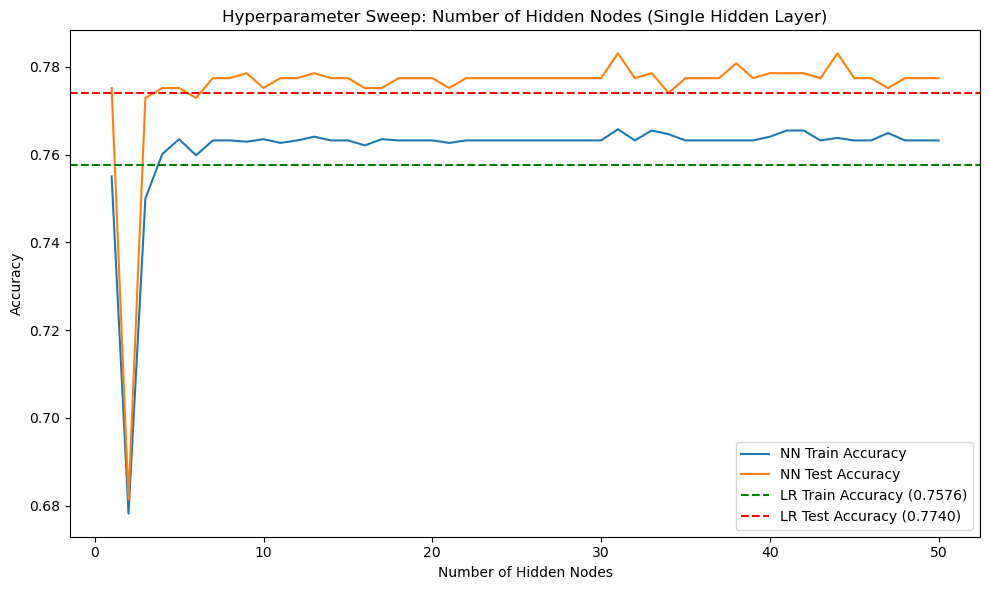

In [ ]:
# Answer Here

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_nn, y_nn, test_size=0.2, random_state=3001
)

# Scale: fit on train, transform both
scaler_sweep = StandardScaler()
X_train_scaled = scaler_sweep.fit_transform(X_train)
X_test_scaled = scaler_sweep.transform(X_test)

# Logistic regression baseline
lr_baseline = LogisticRegression(penalty=None, max_iter=2000, random_state=3001)
lr_baseline.fit(X_train_scaled, y_train)
lr_train_acc = lr_baseline.score(X_train_scaled, y_train)
lr_test_acc = lr_baseline.score(X_test_scaled, y_test)

# Sweep hidden nodes
hidden_nodes_range = range(1, 51)
nn_train_accs = []
nn_test_accs = []

for k in hidden_nodes_range:
    mlp_k = MLPClassifier(
        solver='adam',
        activation='relu',
        hidden_layer_sizes=(k,),
        max_iter=2000,
        random_state=3001
    )
    mlp_k.fit(X_train_scaled, y_train)
    nn_train_accs.append(mlp_k.score(X_train_scaled, y_train))
    nn_test_accs.append(mlp_k.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 6))
plt.plot(list(hidden_nodes_range), nn_train_accs, label='NN Train Accuracy')
plt.plot(list(hidden_nodes_range), nn_test_accs, label='NN Test Accuracy')
plt.axhline(y=lr_train_acc, color='green', linestyle='--', label=f'LR Train Accuracy ({lr_train_acc:.4f})')
plt.axhline(y=lr_test_acc, color='red', linestyle='--', label=f'LR Test Accuracy ({lr_test_acc:.4f})')
plt.xlabel('Number of Hidden Nodes')
plt.ylabel('Accuracy')
plt.title('Hyperparameter Sweep: Number of Hidden Nodes (Single Hidden Layer)')
plt.legend()
plt.tight_layout()
plt.show()

**Q6.6 (2 Points):**

1. Based on the plot above, does your neural network ever perform better than the baseline logistic regression? Point out where on the graph this is true.

**Answer Here:**

EDITED:
Yes, the neural network does outperform the baseline logistic regression at certain numbers of hidden nodes. Specifically, the NN test accuracy exceeds the LR test accuracy (red dashed line) at several points in the mid-range of hidden nodes. The NN train accuracy also generally exceeds the LR train accuracy, particularly as the number of hidden nodes increases. The exact points can be identified where the blue NN test accuracy line rises above the red LR test accuracy line.

2. How could you improve this hyperparameter search to make sure that the neural network is actually outperforming the logistic regression and that it is not just based on the single train/test split?

**Note:** you don't need to execute this improvement right now. Just point out how this analysis could be improved.

**Answer Here:**

EDITED:
Instead of relying on a single train/test split, we could use **k-fold cross-validation** for each value of hidden nodes. This would train and evaluate each model on multiple different splits of the data, giving us a more robust estimate of each model's generalization performance. By averaging the accuracy across all folds, we reduce the variance due to the particular random split and get a more reliable comparison between the neural network and logistic regression.

**Q6.7 (6 Points):** Identify the number of hidden nodes from above that performed the best. Using that value of hidden nodes for all hidden layers and the same train/test spilt, perform a hyperparameter search for the number of hidden layers. Produce the same plot as before, this time with the number of hidden layers on the x-axis.

**Hint:** You can create a tuple with the same *value* repeated *n* times as: `(value,)*n`

Best number of hidden nodes: 31


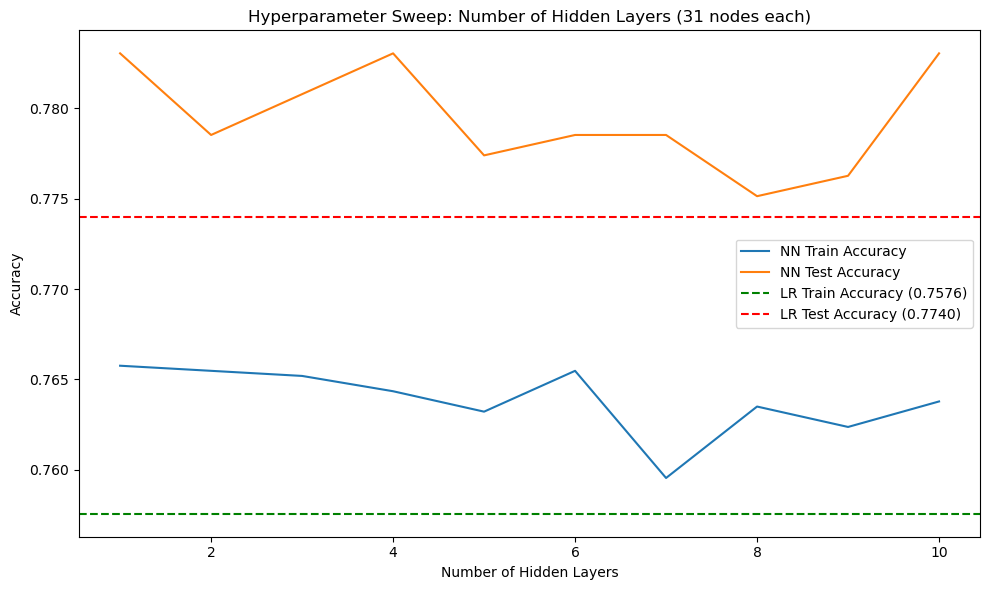

In [ ]:
# Answer Here

# Best number of hidden nodes from Q6.5
best_nodes = list(hidden_nodes_range)[np.argmax(nn_test_accs)]
print(f"Best number of hidden nodes: {best_nodes}")

# Sweep number of hidden layers
layers_range = range(1, 11)
nn_train_accs_layers = []
nn_test_accs_layers = []

for n_layers in layers_range:
    mlp_layers = MLPClassifier(
        solver='adam',
        activation='relu',
        hidden_layer_sizes=(best_nodes,) * n_layers,
        max_iter=2000,
        random_state=3001
    )
    mlp_layers.fit(X_train_scaled, y_train)
    nn_train_accs_layers.append(mlp_layers.score(X_train_scaled, y_train))
    nn_test_accs_layers.append(mlp_layers.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 6))
plt.plot(list(layers_range), nn_train_accs_layers, label='NN Train Accuracy')
plt.plot(list(layers_range), nn_test_accs_layers, label='NN Test Accuracy')
plt.axhline(y=lr_train_acc, color='green', linestyle='--', label=f'LR Train Accuracy ({lr_train_acc:.4f})')
plt.axhline(y=lr_test_acc, color='red', linestyle='--', label=f'LR Test Accuracy ({lr_test_acc:.4f})')
plt.xlabel('Number of Hidden Layers')
plt.ylabel('Accuracy')
plt.title(f'Hyperparameter Sweep: Number of Hidden Layers ({best_nodes} nodes each)')
plt.legend()
plt.tight_layout()
plt.show()

**Q6.8 (2 Points):**

1. Interpret the graph above. What happens as you increase the number of hidden layers here? Compare it to the performance of the logistic regression model.

**Answer Here:**

EDITED:
As the number of hidden layers increases, the neural network's train accuracy tends to stay relatively high or increase, while the test accuracy may fluctuate or decrease. With too many layers, the model can overfit to the training data (high train accuracy but declining test accuracy) or encounter optimization difficulties such as vanishing gradients. Compared to the logistic regression baseline, the neural network may outperform it at certain layer counts but underperform at others, showing that adding more layers does not always improve performance — especially on smaller datasets.

2. Even if the accuracy of the neural network is better on this given train/test split, why might you still favor the logistic regression? List two potential reasons.

**Answer Here:**

EDITED:
1. **Interpretability:** Logistic regression produces coefficients with clear interpretations as log-odds, making it easy to explain which features drive the predictions and by how much. Neural networks are essentially "black boxes" where understanding why a particular prediction was made is much more difficult.

2. **Simplicity and efficiency:** Logistic regression is much faster to train, has far fewer hyperparameters to tune, and is less prone to overfitting on small datasets. If the performance difference is marginal, the simpler model is preferred because it is more robust, easier to maintain, and more reproducible.